In [36]:
# Configuration and File Paths
import sys
import time
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
import geopandas as gpd

from config import get_config, get_development_config, validate_config, setup_directories, print_config_summary
from src.simulation import simulate_asset_damage_recovery_access_breakdown
from src.data_loader import load_hazard_maps, load_electricity_assets
from src.visualization import *
from src.impacts import prepare_population_impact_data, prepare_land_use_impact_data, create_voronoi_for_asset_type
from src.caching import load_simulation_caches
# from src.adaptation import simulate_asset_damage_recovery_access_breakdown_ema

import src.grid_based_accessibility_hex as grid_hex
# Get configuration (currently from config.py)
config = get_config()
# config = get_development_config()

setup_directories(config)

# Print summary
print_config_summary(config)

# Set the hazard extraction method constant
HAZARD_EXTRACTION_METHOD = config['analysis_config']['hazard_extraction_method']
print(f"Hazard extraction method set to: {HAZARD_EXTRACTION_METHOD}")

# Load data
gdf_assets = load_electricity_assets(config['electricity_dir'], asset_types=['msls'])

hazard_maps = load_hazard_maps(config['hazard_dir'], max_days=None)  
print(f"\nHazard maps loaded:")
for i, hm in enumerate(hazard_maps):
    if i < 5:
        print(f"  -{hm}")
    elif i == 5:
        print(f"  and {len(hazard_maps) - 3} more")
        break
# Configure simulation parameters from config
simulation_params = {
    'flood_threshold': config['simulation_config']['flood_threshold'],
    'number_repair_crews': config['simulation_config']['number_repair_crews'],
    'repair_crew_assignment_method': config['simulation_config']['repair_crew_assignment_method'],
    'verbose': config['simulation_config']['verbose'],
    'damage_ratio_coefficients': config['recovery_parameters']['damage_ratio_coefficients'],
    'repair_time_coefficients': config['recovery_parameters']['repair_time_coefficients'],
    'damage_threshold': config['recovery_parameters']['damage_threshold'],
    'repair_threshold': config['recovery_parameters']['repair_threshold'],
    'config': config  # Pass entire config for directory management
}

accessibility_model = None#grid_hex.accessibility_model
simulation_params['accessibility_model'] = accessibility_model

print(f"\nSimulation configuration:")
for key, value in simulation_params.items():
    if key != 'config':  # Don't print the entire config
        print(f"  {key}: {value}")

print(f"\nDirectory structure:")
print(f"  Interim: {config['interim_dir']}")
print(f"  Output: {config['output_dir']}")
print(f"  Cache will be organized by hazard directory: {Path(config['hazard_dir']).name}")



simulation_params['verbose'] = True  # Set verbose to False for cleaner output
simulation_params['flood_threshold'] = 0.2

execution_id = int(time.time())
print(f"***Starting simulation execution {execution_id}***")

max_days = None#config['analysis_config']['max_simulation_days']

caches = load_simulation_caches(config['interim_dir'], config['hazard_dir'])
print(f"Loaded caches: {[k for k in caches.keys() if caches[k] is not None]}")

# Run the  simulation
results_df, final_state, cache_updated = simulate_asset_damage_recovery_access_breakdown(
    gdf_assets=gdf_assets,
    hazard_maps=hazard_maps[:max_days],
    number_repair_crews=simulation_params['number_repair_crews'],
    repair_crew_assignment_method=simulation_params['repair_crew_assignment_method'],
    flood_threshold=simulation_params['flood_threshold'],
    recovery_parameters=config['recovery_parameters'],
    root_dir=config['root_dir'],
    verbose=simulation_params['verbose'], 
    timestep_output=True, 
    execution_id=execution_id,
    config=config, 
    major_timestep=6,
    accessibility_cache=caches.get('accessibility_cache'),
    hazard_extraction_cache=caches.get('hazard_extraction_cache'),
    overlap_cache=caches.get('overlap_cache'),
    island_cache=caches.get('island_cache'),
    fragility_param_k=config['simulation_config'].get('fragility_param_k', 5.0)
)


print(f"\n***Completed simulation execution {execution_id}***")

c:\Users\peregrin\AppData\Local\miniconda3\envs\miraca_template\Lib\site-packages\ema_workbench\em_framework\__init__.py:101: UserWarning: ipyparallel not installed - IpyparalleEvaluator not available
  warnings.warn("ipyparallel not installed - IpyparalleEvaluator not available")



Configuration Summary
Root directory: c:\repos\powerpath\powerpath
Assets data: c:\repos\powerpath\powerpath\raw_data\ZH_Delfland\electricity
Hazard data: c:\repos\powerpath\powerpath\raw_data\ZH_Delfland_interpolated_timesteps_tif\hazard_maps_ZH_Delfland
Interim directory: c:\repos\powerpath\powerpath\data\interim\interim_hazard_maps_ZH_Delfland
Output directory: c:\repos\powerpath\powerpath\data\output\output_hazard_maps_ZH_Delfland

Simulation Configuration:
  number_repair_crews: 20
  repair_crew_assignment_method: islands
  flood_threshold: 0.2
  verbose: True
  accessibility_model: None

Recovery Parameters:
  repair_time_coefficients: [702.72, 3.14, 1.9891]
  damage_ratio_coefficients: (0.0468, 0.0077)
  time_step_hours: 1
  damage_threshold: 0.01
  repair_threshold: 2.0

Analysis Configuration:
  hazard_extraction_method: max
  max_simulation_days: None
  cache_enabled: True
  performance_monitoring: False
Hazard extraction method set to: max
Found 1 electricity station files 

In [37]:
import matplotlib.animation as animation
from matplotlib.colors import Normalize
import matplotlib.pyplot as plt
import rasterio
import contextily as cx
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patches as patches

import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent.parent))


from rasterio import features
from shapely.geometry import shape

import re

import pandas as pd
from shapely.geometry import Point



In [38]:
# for compatibility with older versions of Shapely, a fallback geometry fixing function is provided
try:
    from shapely import make_valid
    def _fix_geom(geom):
        g = make_valid(geom)
        return g if not g.is_empty else geom
except Exception:
    def _fix_geom(geom):
        # Fallback: buffer(0) often fixes ring self-intersections
        g = geom.buffer(0)
        return g if not g.is_empty else geom


In [ ]:
# set directory paths and parameters
src_dir = Path(r'C:\repos\powerpath\powerpath\raw_data\ZH_Delfland_interpolated_timesteps_tif\hazard_maps_ZH_Delfland')
dest_dir = Path(r'C:\repos\powerpath\powerpath\raw_data\ZH_Delfland_interpolated_timesteps_tif\hazard_maps_ZH_Delfland_vectorized')
dest_dir.mkdir(parents=True, exist_ok=True)

threshold = 0.2


In [ ]:
# in this case, files are numbered 0, 1, 2, ... 10, so we sort by the numeric part of the filename to ensure correct order (avoiding 0, 1, 10, 11, ..., 19, 2, 20, ...)
for tif_file in sorted(src_dir.glob('*.tif')):
    print("Processing:", tif_file.name)

    with rasterio.open(tif_file) as src:
        data = src.read(1)
        transform = src.transform
        crs = src.crs
        nodata = src.nodata

    valid = ~np.isnan(data)
    if nodata is not None:
        valid &= data != nodata
    mask = valid & (data >= threshold)

    polygons = []

    if np.any(mask):
        for geom_mapping, val in features.shapes(
            mask.astype(np.uint8),
            mask=mask,
            transform=transform,
            connectivity=8
        ):
            if val == 1:
                geom = shape(geom_mapping)
                if not geom.is_valid:
                    geom = _fix_geom(geom)
                if not geom.is_empty:
                    polygons.append(geom)

    # this always executes, even if polygons is empty.
    gdf = gpd.GeoDataFrame(
        {"value": [1] * len(polygons)},
        geometry=polygons,
        crs=crs
    )

    out_path = dest_dir / f"{tif_file.stem}_vectorized.geojson"
    gdf.to_file(out_path, driver="GeoJSON")
    print("Saved:", out_path.name, "with", len(gdf), "polygons")

Processing: timestep_0.tif
Saved: timestep_0_vectorized.geojson with 0 polygons
Processing: timestep_1.tif
Saved: timestep_1_vectorized.geojson with 6354 polygons
Processing: timestep_10.tif
Saved: timestep_10_vectorized.geojson with 57029 polygons
Processing: timestep_11.tif
Saved: timestep_11_vectorized.geojson with 56454 polygons
Processing: timestep_12.tif
Saved: timestep_12_vectorized.geojson with 56094 polygons
Processing: timestep_13.tif
Saved: timestep_13_vectorized.geojson with 56374 polygons
Processing: timestep_14.tif
Saved: timestep_14_vectorized.geojson with 55312 polygons
Processing: timestep_15.tif
Saved: timestep_15_vectorized.geojson with 54110 polygons
Processing: timestep_16.tif
Saved: timestep_16_vectorized.geojson with 53170 polygons
Processing: timestep_17.tif
Saved: timestep_17_vectorized.geojson with 52766 polygons
Processing: timestep_18.tif
Saved: timestep_18_vectorized.geojson with 51629 polygons
Processing: timestep_19.tif
Saved: timestep_19_vectorized.geojs

Building timesteps_df: 198 timesteps (hours), 5858 assets
timesteps_df shape: (1159884, 11)
Found 7918 major road segments
Using 'operational' for operational state
Animating EV frames: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)] ... [np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32)]
Saved: C:\repos\powerpath\powerpath\raw_data\ZH_Delfland_interpolated_timesteps_tif\hazard_maps_ZH_Delfland_vectorized\flood_assets_timelapse_4x3.gif


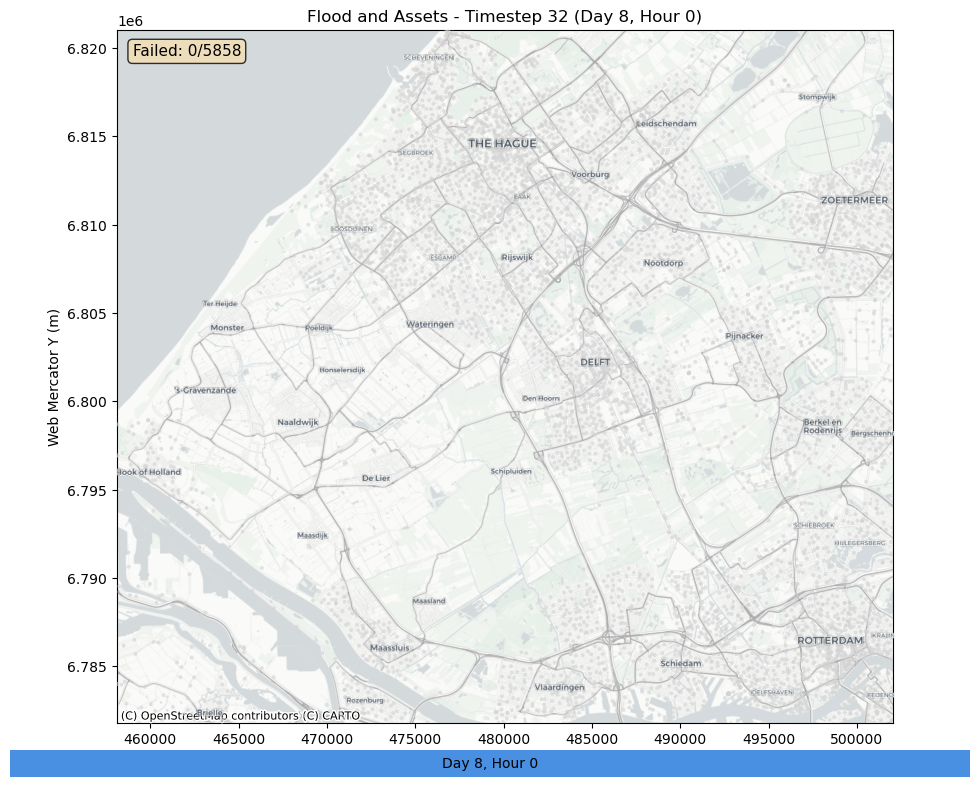

In [44]:
# --- imports ---
import os
import re
import pickle
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import contextily as cx
from shapely.geometry import Point
import matplotlib.patches as patches

# ==============================================
# helpers
# ==============================================
def extract_timestep(path):
    m = re.search(r'timestep_(\d+)', path.stem)
    if m:
        return int(m.group(1))
    return None

def timestep_to_day_hour(t):
    total_hours = t * 6
    day = total_hours // 24
    hour = total_hours % 24
    return int(day), int(hour)

def contains_major_road(highway_val):
    major_road_types = {'trunk', 'trunk_link', 'motorway', 'motorway_link',
                        'primary', 'primary_link', 'secondary', 'secondary_link'}
    if isinstance(highway_val, list):
        return any(rd_type in highway_val for rd_type in major_road_types)
    hw_str = str(highway_val).lower()
    return any(rd_type in hw_str for rd_type in major_road_types)

# ==============================================
# build timesteps_df (assets hourly results)
# expects: results_df in memory with results_df[0][2] = list of dicts per hour
# ==============================================
detailed_results = results_df[0][2]

num_timesteps = len(detailed_results)
if num_timesteps > 0:
    num_assets = len(detailed_results[0].get('operational', []))
else:
    num_assets = 0

print("Building timesteps_df: %d timesteps (hours), %d assets" % (num_timesteps, num_assets))

rows = []
for hour in range(num_timesteps):
    rec = detailed_results[hour]
    for a in range(num_assets):
        r = {'timestep': hour, 'asset_id': a}  # timestep here is hour index
        for key, values in rec.items():
            if hasattr(values, '__len__') and len(values) == num_assets:
                r[key] = values[a]
        rows.append(r)

timesteps_df = pd.DataFrame(rows)
print("timesteps_df shape:", timesteps_df.shape)

# ==============================================
# load vectorized flood polygons (EV t = 0..N)
# expects: dest_dir defined and containing timestep_{t}_vectorized.geojson
# ==============================================
from pathlib import Path
vec_dir = dest_dir
files = sorted(vec_dir.glob("*.geojson"))
files_sorted = sorted(files, key=lambda p: extract_timestep(p))

loaded_files = []
template = None
for f in files_sorted:
    t = extract_timestep(f)
    gdf = gpd.read_file(f)
    loaded_files.append((t, gdf))
    if template is None and len(gdf) > 0:
        template = gdf.head(0).copy()

if template is None:
    template = gpd.GeoDataFrame({"value": pd.Series(dtype="float64")},
                                geometry=pd.GeoSeries(dtype="geometry"),
                                crs="EPSG:4326")

if "timestep" not in template.columns:
    template["timestep"] = pd.Series(dtype="int64")

gdfs = []
for t, gdf in loaded_files:
    if len(gdf) == 0:
        empty = template.head(0).copy()
        empty.loc[0, :] = None
        empty["timestep"] = t
        gdfs.append(empty)
    else:
        gdf["timestep"] = t
        gdfs.append(gdf)

gdf_time_flood = pd.concat(gdfs, ignore_index=True)

# give empty frames a dummy geometry so they are kept through operations
xmin, ymin, xmax, ymax = gdf_time_flood.total_bounds
dummy_point = Point(xmin, ymin)
gdf_time_flood["geometry"] = gdf_time_flood["geometry"].fillna(dummy_point)
gdf_time_flood = gpd.GeoDataFrame(gdf_time_flood, geometry="geometry", crs=gdf_time_flood.crs)

# ==============================================
# roads (from pickled graph) and major road filter
# expects: graph_data_path defined and geometries present on 'geometry'
# ==============================================
graph_data_path = r'C:/repos/powerpath/data/ZH_Delfland_interpolated_timesteps_tif/static/output_graph/base_graph_hazard_editted.p'
with open(graph_data_path, "rb") as f:
    graph_data = pickle.load(f)

edge_records = []
for u, v, d in graph_data.edges(data=True):
    rec = {'u': u, 'v': v}
    rec.update(d)
    edge_records.append(rec)

G_df = gpd.GeoDataFrame(edge_records, geometry='geometry', crs="EPSG:4326")
major_roads = G_df[G_df['highway'].apply(contains_major_road)].copy()
print("Found %d major road segments" % len(major_roads))

# ==============================================
# assets: align hourly data to EV indices (keep only hours that are multiples of 6)
# Hour 0 -> EV0, Hour 6 -> EV1, ...
# ==============================================
# ensure merge key types match
timesteps_df['asset_id'] = timesteps_df['asset_id'].astype(int)
gdf_assets = gdf_assets.copy()
gdf_assets.index = gdf_assets.index.astype(int)

# filter hourly rows that align exactly with EV frames, compute ev index
assets_ev = timesteps_df[timesteps_df['timestep'] % 6 == 0].copy()
assets_ev['ev'] = (assets_ev['timestep'] // 6).astype(int)

# choose operational column name later after merge
df_assets = assets_ev.merge(
    gdf_assets[['geometry']],
    left_on='asset_id', right_index=True, how='left'
)
gdf_time_assets = gpd.GeoDataFrame(df_assets, geometry='geometry', crs=gdf_assets.crs)

# choose operational-like column
if 'operational' in gdf_time_assets.columns:
    state_col = 'operational'
else:
    state_col = 'damage_ratio'
print("Using '%s' for operational state" % state_col)

# ==============================================
# reproject everything to EPSG:3857 for contextily and centroids
# ==============================================
gdf_time_flood_3857 = gdf_time_flood.to_crs(epsg=3857)
gdf_time_assets_3857 = gdf_time_assets.to_crs(epsg=3857)
major_roads_3857 = major_roads.to_crs(epsg=3857)

gdf_time_assets_3857['centroid'] = gdf_time_assets_3857.geometry.centroid

# frames strictly from flood EVs (e.g., 0..32)
flood_ts = sorted(gdf_time_flood_3857['timestep'].dropna().astype(int).unique())
timesteps = flood_ts
print("Animating EV frames:", timesteps[:5], "...", timesteps[-5:] if len(timesteps) > 5 else timesteps)

# plot extent
xmin, ymin, xmax, ymax = gdf_time_flood_3857.total_bounds
padding = 500
xlim = (xmin - padding, xmax + padding)
ylim = (ymin - padding, ymax + padding)

# contextily caching dir (modern approach via env var)
# os.environ["REQUESTS_CACHE_PATH"] = str(vec_dir / "contextily_cache")
cx.set_cache_dir(vec_dir / "contextily_cache")

# ==============================================
# animation with progress bar and CartoDB basemap
# ==============================================
fig, ax = plt.subplots(figsize=(12, 9))  # 4:3

# progress bar axis
progress_ax = fig.add_axes([0.1, 0.05, 0.8, 0.03])
progress_ax.set_xlim(0, 1)
progress_ax.set_ylim(0, 1)
progress_ax.axis("off")

bg_rect = patches.Rectangle((0, 0), 1, 1, facecolor="#dddddd", edgecolor="none", linewidth=0)
progress_ax.add_patch(bg_rect)
fg_rect = patches.Rectangle((0, 0), 0, 1, facecolor="#4a90e2", edgecolor="none", linewidth=0)
progress_ax.add_patch(fg_rect)
progress_text = progress_ax.text(0.5, 0.5, "", ha="center", va="center", fontsize=10, color="black")

def animate(frame):
    ax.clear()

    t = timesteps[frame]

    # select current layers
    flood_cur = gdf_time_flood_3857[gdf_time_flood_3857["timestep"] == t]
    # assets filtered by EV index, not by hour
    assets_cur = gdf_time_assets_3857[gdf_time_assets_3857["ev"] == t]

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    # basemap underlays
    cx.add_basemap(ax, crs="EPSG:3857", source=cx.providers.CartoDB.Positron, zoom=12)
    cx.add_basemap(ax, crs="EPSG:3857", source=cx.providers.CartoDB.PositronOnlyLabels, zoom=12)

    # layer 1: major roads with EV t exposure column if present
    ev_col = f"EV{t}_ma"
    if ev_col in major_roads_3857.columns:
        road_colors = major_roads_3857[ev_col].apply(
            lambda x: 'red' if pd.notnull(x) and x >= 0.2 else 'darkgrey'
        )
        major_roads_3857.plot(ax=ax, color=road_colors, linewidth=0.8, zorder=1, alpha=0.6)
    else:
        major_roads_3857.plot(ax=ax, color="darkgrey", linewidth=0.8, zorder=1, alpha=0.6)

    # layer 2: flood polygons
    if len(flood_cur) > 0:
        flood_cur.plot(ax=ax, facecolor="#a7d3ff", edgecolor="none", linewidth=0.0, alpha=0.75, zorder=2)

    # layer 3: assets
    if len(assets_cur) > 0:
        if state_col == 'operational':
            ops_mask = assets_cur[state_col] == 1
        else:
            # treat damage_ratio == 0 as operational
            ops_mask = assets_cur[state_col].fillna(0) == 0

        cent = assets_cur['centroid']

        # operational assets
        if ops_mask.sum() > 0:
            ax.scatter(cent[ops_mask].x, cent[ops_mask].y,
                       marker='o', c='lightgrey', s=8, zorder=3,
                       edgecolors='none', alpha=0.6)

        # non-operational assets colored by status
        if (~ops_mask).sum() > 0:
            non_ops = assets_cur[~ops_mask]
            non_ops_cent = cent[~ops_mask]

            def get_asset_color(row):
                if row.get('flooded') == 1:
                    return 'red'
                elif row.get('unreachable') == 1:
                    return 'orange'
                elif row.get('crew_assigned') == 1:
                    return 'yellow'
                else:
                    return 'lightgrey'
            colors = non_ops.apply(get_asset_color, axis=1)

            ax.scatter(non_ops_cent.x, non_ops_cent.y,
                       marker='o', c=colors, s=50, zorder=4,
                       edgecolors='black', linewidth=0.8, alpha=0.9)

    # titles and labels
    day, hour = timestep_to_day_hour(t)
    ax.set_title("Flood and Assets - Timestep %d (Day %d, Hour %d)" % (t, day, hour))
    ax.set_xlabel("Web Mercator X (m)")
    ax.set_ylabel("Web Mercator Y (m)")
    ax.grid(False)

    # quick text summary for assets
    n_total = len(assets_cur)
    if n_total > 0:
        if state_col == 'operational':
            n_failed = (assets_cur[state_col] != 1).sum()
        else:
            n_failed = (assets_cur[state_col].fillna(0) != 0).sum()
        ax.text(0.02, 0.98, "Failed: %d/%d" % (n_failed, n_total),
                transform=ax.transAxes, fontsize=11, va='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

    # progress bar
    fraction = t / (len(timesteps) - 1) if len(timesteps) > 1 else 1.0
    fg_rect.set_width(fraction)
    progress_text.set_text("Day %d, Hour %d" % (day, hour))

    return ax,

anim = animation.FuncAnimation(
    fig,
    animate,
    frames=len(timesteps),
    interval=500,
    blit=False,
    repeat=True
)

# save at 4:3, high DPI
out_gif = dest_dir / "flood_assets_timelapse_4x3.gif"
anim.save(out_gif, writer="pillow", dpi=150, fps=5)
print("Saved:", out_gif)

plt.show()


Building timesteps_df: 198 timesteps, 5858 assets
columns in timesteps_df: ['timestep', 'asset_id', 'damage_ratio', 'repair_time', 'operational', 'accessible', 'unreachable', 'flooded', 'crew_assigned', 'hazard_value', 'island_id']
using operational for operational state
gdf_assets CRS: EPSG:4326
Found 7918 major road segments
Saved: C:\repos\powerpath\powerpath\raw_data\ZH_Delfland_interpolated_timesteps_tif\hazard_maps_ZH_Delfland_vectorized\flood_assets_timelapse_4x3.gif


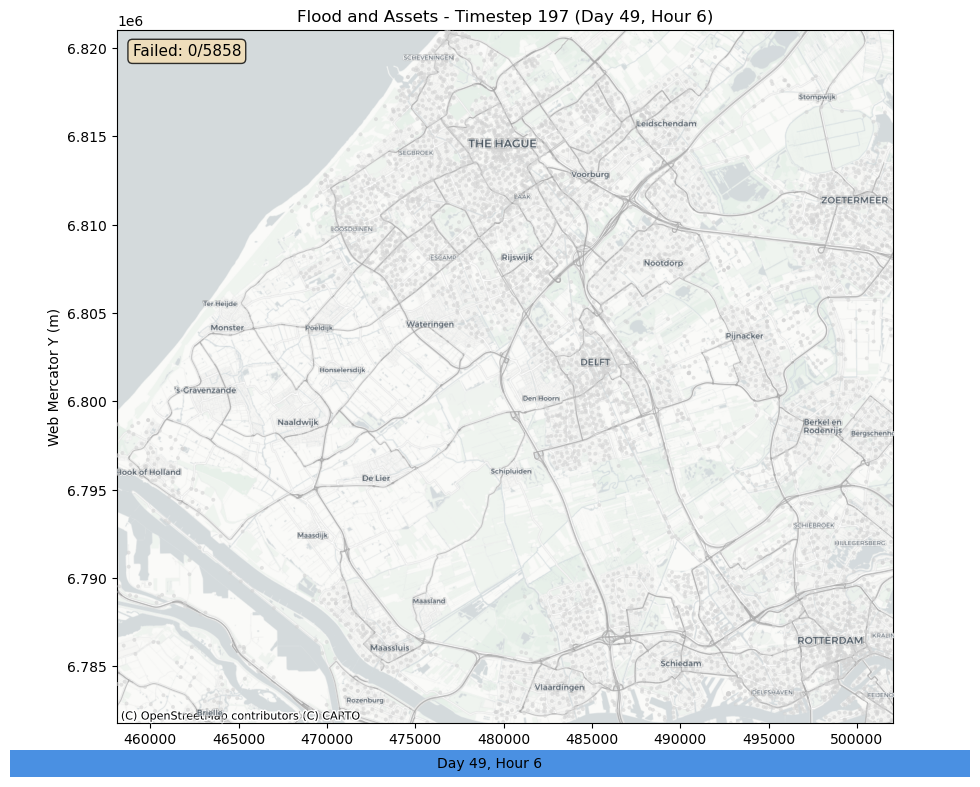

In [ ]:
# --- imports ---
import os
import re
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import contextily as cx
from shapely.geometry import Point
import matplotlib.patches as patches
import pickle

# --- helpers ---
def extract_timestep(path):
    m = re.search(r'timestep_(\d+)', path.stem)
    if m:
        return int(m.group(1))
    return None

def timestep_to_day_hour(t):
    total_hours = t * 6
    day = total_hours // 24
    hour = total_hours % 24
    return int(day), int(hour)

def contains_major_road(highway_val):
    major_road_types = {'trunk', 'trunk_link', 'motorway', 'motorway_link',
                        'primary', 'primary_link', 'secondary', 'secondary_link'}
    if isinstance(highway_val, list):
        return any(rd_type in highway_val for rd_type in major_road_types)
    hw_str = str(highway_val).lower()
    return any(rd_type in hw_str for rd_type in major_road_types)
# Access the detailed results (list of dicts, one per timestep)
detailed_results = results_df[0][2]

# Determine the number of timesteps and assets
num_timesteps = len(detailed_results)
if num_timesteps > 0:
    # Use a reference key (e.g., 'operational') to get asset count
    num_assets = len(detailed_results[0].get('operational', []))
else:
    num_assets = 0

print(f"Building timesteps_df: {num_timesteps} timesteps, {num_assets} assets")

# Build a list of dictionaries for the DataFrame
data = []
for t in range(num_timesteps):
    timestep_data = detailed_results[t]
    for a in range(num_assets):
        row = {'timestep': t, 'asset_id': a}
        # Add metric values for this asset at this timestep
        # Changed: Check for any sequence with the correct length (handles lists, arrays, etc.)
        for key, values in timestep_data.items():
            if hasattr(values, '__len__') and len(values) == num_assets:
                row[key] = values[a]
        data.append(row)

# Create the DataFrame
timesteps_df = pd.DataFrame(data)


# --- load flood polygons (vectorized GeoJSONs) ---
vec_dir = dest_dir  # you already defined dest_dir earlier
files = sorted(vec_dir.glob('*.geojson'))
files_sorted = sorted(files, key=lambda p: extract_timestep(p))

loaded_files = []
template = None
for f in files_sorted:
    t = extract_timestep(f)
    gdf = gpd.read_file(f)
    loaded_files.append((t, gdf))
    if template is None and len(gdf) > 0:
        template = gdf.head(0).copy()

if template is None:
    template = gpd.GeoDataFrame({"value": pd.Series(dtype="float64")},
                                geometry=pd.GeoSeries(dtype="geometry"),
                                crs="EPSG:4326")

if "timestep" not in template.columns:
    template["timestep"] = pd.Series(dtype="int64")

gdfs = []
for t, gdf in loaded_files:
    if len(gdf) == 0:
        empty = template.head(0).copy()
        empty.loc[0, :] = None
        empty["timestep"] = t
        gdfs.append(empty)
    else:
        gdf["timestep"] = t
        gdfs.append(gdf)

gdf_time_flood = pd.concat(gdfs, ignore_index=True)

# ensure a geometry for empty timesteps so concat never drops them later
xmin, ymin, xmax, ymax = gdf_time_flood.total_bounds
dummy_point = Point(xmin, ymin)
gdf_time_flood["geometry"] = gdf_time_flood["geometry"].fillna(dummy_point)
gdf_time_flood = gpd.GeoDataFrame(gdf_time_flood, geometry="geometry", crs=gdf_time_flood.crs)

# --- assets and roads preparation (as in your earlier code), then project to 3857 ---
# bring the asset geometry in, using asset_id as key
# NOTE: we reproject geometries after building the GeoDataFrame, then compute centroids in projected CRS
print("columns in timesteps_df:", timesteps_df.columns.tolist())
df_assets = timesteps_df.merge(
    gdf_assets[['geometry']],  # geometry only from gdf_assets
    left_on='asset_id', right_index=True, how='left'
)
gdf_time_assets = gpd.GeoDataFrame(df_assets, geometry='geometry', crs=gdf_assets.crs)

# choose operational column
if 'operational' in gdf_time_assets.columns:
    state_col = 'operational'
else:
    state_col = 'damage_ratio'
print("using", state_col, "for operational state")
print("gdf_assets CRS:", gdf_assets.crs)

# filter major roads
graph_data_path = r'C:/repos/powerpath/data/ZH_Delfland_interpolated_timesteps_tif/static/output_graph/base_graph_hazard_editted.p'
with open(graph_data_path, 'rb') as f:
    graph_data = pickle.load(f)

# build a list of edge‑records
edge_records = []
for u, v, d in graph_data.edges(data=True):
    rec = {'u': u, 'v': v}
    rec.update(d)            # copy any attributes (including ‘geometry’)
    edge_records.append(rec)

# create GeoDataFrame – assume the edge dicts contain a shapely
# geometry under the key 'geometry'; set CRS if known
G_df = gpd.GeoDataFrame(edge_records, geometry='geometry', crs="EPSG:4326")

major_roads = G_df[G_df['highway'].apply(contains_major_road)].copy()
print("Found", len(major_roads), "major road segments")

# --- reproject everything to EPSG:3857 for plotting with contextily ---
gdf_time_flood_3857 = gdf_time_flood.to_crs(epsg=3857)
gdf_time_assets_3857 = gdf_time_assets.to_crs(epsg=3857)
major_roads_3857 = major_roads.to_crs(epsg=3857)

# centroids for point markers computed in projected CRS
gdf_time_assets_3857['centroid'] = gdf_time_assets_3857.geometry.centroid

# --- frame set: union of timesteps present in floods and assets ---
flood_ts = set(gdf_time_flood_3857['timestep'].dropna().astype(int).unique())
asset_ts = set(gdf_time_assets_3857['timestep'].dropna().astype(int).unique())
timesteps = sorted(flood_ts.union(asset_ts))

# --- plot extent (Web Mercator meters) ---
xmin, ymin, xmax, ymax = gdf_time_flood_3857.total_bounds
padding = 500
xlim = (xmin - padding, xmax + padding)
ylim = (ymin - padding, ymax + padding)

# --- contextily caching (modern way) ---
# os.environ["REQUESTS_CACHE_PATH"] = str(vec_dir / "contextily_cache")
cx.set_cache_dir(vec_dir / "contextily_cache")

# --- 4:3 figure and progress bar axis ---
fig, ax = plt.subplots(figsize=(12, 9))  # 4:3
progress_ax = fig.add_axes([0.1, 0.05, 0.8, 0.03])
progress_ax.set_xlim(0, 1)
progress_ax.set_ylim(0, 1)
progress_ax.axis("off")

bg_rect = patches.Rectangle((0, 0), 1, 1, facecolor="#dddddd", edgecolor="none", linewidth=0)
progress_ax.add_patch(bg_rect)
fg_rect = patches.Rectangle((0, 0), 0, 1, facecolor="#4a90e2", edgecolor="none", linewidth=0)
progress_ax.add_patch(fg_rect)
progress_text = progress_ax.text(0.5, 0.5, "", ha="center", va="center", fontsize=10, color="black")

def animate(frame):
    ax.clear()

    t = timesteps[frame]

    # select per-layer data for this timestep
    flood_cur = gdf_time_flood_3857[gdf_time_flood_3857["timestep"] == t]
    assets_cur = gdf_time_assets_3857[gdf_time_assets_3857["timestep"] == t]

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    # basemap + labels
    cx.add_basemap(ax, crs="EPSG:3857", source=cx.providers.CartoDB.Positron, zoom=12)
    cx.add_basemap(ax, crs="EPSG:3857", source=cx.providers.CartoDB.PositronOnlyLabels, zoom=12)

    # layer 1: major roads
    if len(major_roads_3857) > 0:
        # timestep to EV index
        # n = t // 6
        ev_col = f"EV{t}_ma"
        if ev_col in major_roads_3857.columns:
            road_colors = major_roads_3857[ev_col].apply(lambda x: 'red' if pd.notnull(x) and x >= 0.2 else 'darkgrey')
            major_roads_3857.plot(ax=ax, color=road_colors, linewidth=0.8, zorder=1, alpha=0.6)
        else:
            major_roads_3857.plot(ax=ax, color="darkgrey", linewidth=0.8, zorder=1, alpha=0.6)

    # layer 2: flood polygons (light blue face, transparent edges)
    if len(flood_cur) > 0:
        flood_cur.plot(ax=ax, facecolor="#a7d3ff", edgecolor="none", linewidth=0.0, alpha=0.75, zorder=2)

    # layer 3: assets by operational state
    if len(assets_cur) > 0:
        if state_col == 'operational':
            ops_mask = assets_cur[state_col] == 1
        else:
            # treat damage_ratio == 0 as operational
            ops_mask = assets_cur[state_col].fillna(0) == 0

        cent = assets_cur['centroid']

        # operational assets
        if ops_mask.sum() > 0:
            ax.scatter(cent[ops_mask].x, cent[ops_mask].y,
                       marker='o', c='lightgrey', s=8, zorder=3,
                       edgecolors='none', alpha=0.6)

        # non-operational assets colored by status
        if (~ops_mask).sum() > 0:
            non_ops = assets_cur[~ops_mask]
            non_ops_cent = cent[~ops_mask]

            def get_asset_color(row):
                if row.get('flooded') == 1:
                    return 'red'
                elif row.get('unreachable') == 1:
                    return 'orange'
                elif row.get('crew_assigned') == 1:
                    return 'yellow'
                else:
                    return 'lightgrey'
            colors = non_ops.apply(get_asset_color, axis=1)

            ax.scatter(non_ops_cent.x, non_ops_cent.y,
                       marker='o', c=colors, s=50, zorder=4,
                       edgecolors='black', linewidth=0.8, alpha=0.9)

    # title and axes
    day, hour = timestep_to_day_hour(t)
    ax.set_title("Flood and Assets - Timestep %d (Day %d, Hour %d)" % (t, day, hour))
    ax.set_xlabel("Web Mercator X (m)")
    ax.set_ylabel("Web Mercator Y (m)")
    ax.grid(False)

    # quick text summary
    n_total = len(assets_cur)
    if n_total > 0:
        if state_col == 'operational':
            n_failed = (assets_cur[state_col] != 1).sum()
        else:
            n_failed = (assets_cur[state_col].fillna(0) != 0).sum()
        ax.text(0.02, 0.98, "Failed: %d/%d" % (n_failed, n_total),
                transform=ax.transAxes, fontsize=11, va='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

    # progress bar update
    fraction = t / (len(timesteps) - 1) if len(timesteps) > 1 else 1.0
    fg_rect.set_width(fraction)
    progress_text.set_text("Day %d, Hour %d" % (day, hour))

    return ax,

anim = animation.FuncAnimation(
    fig,
    animate,
    frames=len(timesteps),
    interval=500,
    blit=False,
    repeat=True
)

# save at 4:3, high DPI
out_gif = dest_dir / "flood_assets_timelapse_4x3.gif"
anim.save(out_gif, writer="pillow", dpi=150, fps=5)
print("Saved:", out_gif)

plt.show()

# Functional animation checkpoint

Unique timesteps: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32)]


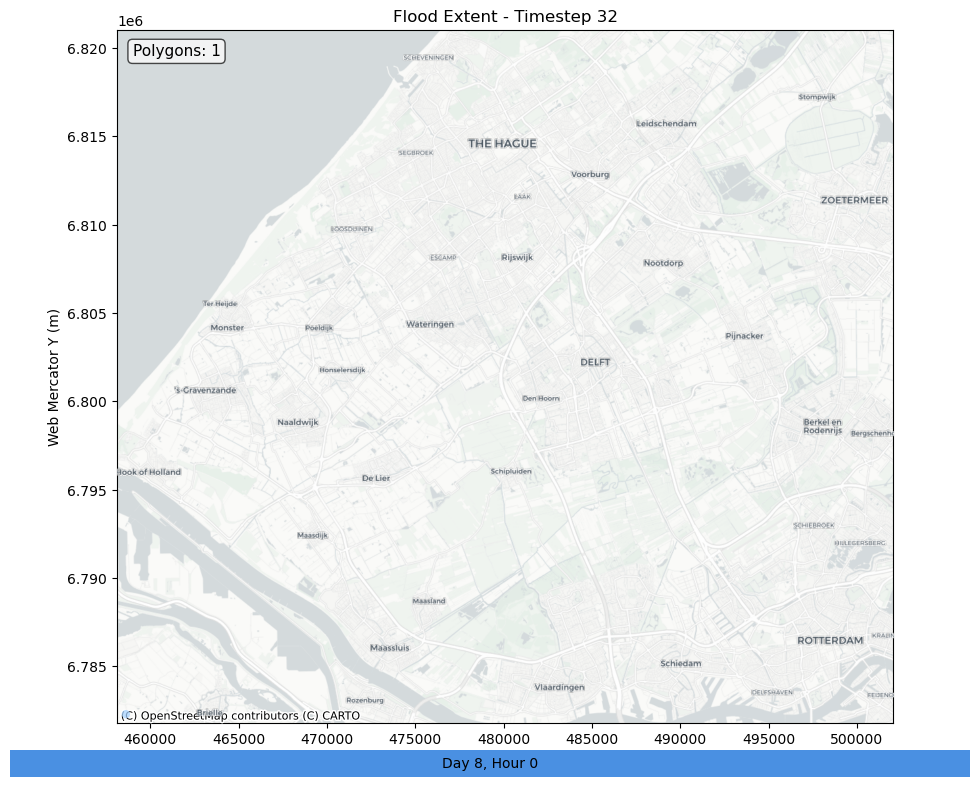

In [35]:
# directory where vectorized files are stored
vec_dir = dest_dir
files = sorted(vec_dir.glob('*.geojson'))

def extract_timestep(path):
    m = re.search(r'timestep_(\d+)', path.stem)
    if m:
        return int(m.group(1))
    return None

def timestep_to_day_hour(t):
    total_hours = t * 6
    day = total_hours // 24
    hour = total_hours % 24
    return int(day), int(hour)

files_sorted = sorted(files, key=lambda p: extract_timestep(p))
loaded_files = []
template = None

for f in files_sorted:
    t = extract_timestep(f)
    gdf = gpd.read_file(f)
    loaded_files.append((t, gdf))
    if template is None and len(gdf) > 0:
        template = gdf.head(0).copy()

if template is None:
    template = gpd.GeoDataFrame({"value": pd.Series(dtype="float64")},
                                geometry=pd.GeoSeries(dtype="geometry"),
                                crs="EPSG:4326")

if "timestep" not in template.columns:
    template["timestep"] = pd.Series(dtype="int64")

gdfs = []
for t, gdf in loaded_files:
    if len(gdf) == 0:
        empty = template.head(0).copy()
        empty.loc[0, :] = None
        empty["timestep"] = t
        gdfs.append(empty)
    else:
        gdf["timestep"] = t
        gdfs.append(gdf)

gdf_time = pd.concat(gdfs, ignore_index=True)

xmin, ymin, xmax, ymax = gdf_time.total_bounds
dummy_point = Point(xmin, ymin)
gdf_time["geometry"] = gdf_time["geometry"].fillna(dummy_point)

gdf_time = gpd.GeoDataFrame(gdf_time, geometry="geometry", crs=gdf_time.crs)

print("Unique timesteps:", sorted(gdf_time["timestep"].unique()))

# ----------------------------------------------
# REPROJECT TO EPSG:3857 FOR CONTEXTILY
# ----------------------------------------------

gdf_time_3857 = gdf_time.to_crs(epsg=3857)

xmin, ymin, xmax, ymax = gdf_time_3857.total_bounds
padding = 500
xlim = (xmin - padding, xmax + padding)
ylim = (ymin - padding, ymax + padding)

timesteps = sorted(gdf_time_3857["timestep"].unique())

# ----------------------------------------------
# CONTEXTILY SETTINGS: USE LOCAL CACHE
# ----------------------------------------------

cx.set_cache_dir(vec_dir / "contextily_cache")
# cx.set_cache(True)

# ----------------------------------------------
# ANIMATION
# ----------------------------------------------

fig, ax = plt.subplots(figsize=(12, 9))

# progress bar axis (small bar at bottom)
progress_ax = fig.add_axes([0.1, 0.05, 0.8, 0.03])  # left, bottom, width, height
progress_ax.set_xlim(0, 1)
progress_ax.set_ylim(0, 1)
progress_ax.axis("off")

# background bar (light grey)
bg_rect = patches.Rectangle((0, 0), 1, 1, facecolor="#dddddd", edgecolor="none", linewidth=0)
progress_ax.add_patch(bg_rect)

# foreground bar (blue), width will be updated
fg_rect = patches.Rectangle((0, 0), 0, 1, facecolor="#4a90e2", edgecolor="none", linewidth=0)
progress_ax.add_patch(fg_rect)

# progress text
progress_text = progress_ax.text(
    0.5, 0.5, "",
    ha="center", va="center",
    fontsize=10,
    color="black"
)

def animate(frame):
    ax.clear()

    t = timesteps[frame]
    gcur = gdf_time_3857[gdf_time_3857["timestep"] == t]

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    cx.add_basemap(
        ax,
        crs="EPSG:3857",
        source=cx.providers.CartoDB.Positron,
        zoom=12
    )

    cx.add_basemap(
        ax,
        crs="EPSG:3857",
        source=cx.providers.CartoDB.PositronOnlyLabels,
        zoom=12
    )

    if len(gcur) > 0:
        gcur.plot(
            ax=ax,
            facecolor="#a7d3ff",
            edgecolor="none",
            linewidth=0.0,
            alpha=0.75,
            zorder=3
        )

    ax.set_title("Flood Extent - Timestep %d" % t)
    ax.set_xlabel("Web Mercator X (m)")
    ax.set_ylabel("Web Mercator Y (m)")
    ax.grid(False)

    ax.text(
        0.02, 0.98,
        "Polygons: %d" % len(gcur),
        transform=ax.transAxes,
        fontsize=11,
        verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.7)
    )

    # update progress bar
    fraction = t / (len(timesteps) - 1)
    fg_rect.set_width(fraction)

    day, hour = timestep_to_day_hour(t)
    progress_text.set_text("Day %d, Hour %d" % (day, hour))

    return ax,


anim = animation.FuncAnimation(
    fig,
    animate,
    frames=len(timesteps),
    interval=500,
    blit=False,
    repeat=True
)

# ----------------------------------------------
# HIGH DPI SAVE
# ----------------------------------------------

anim.save(
    dest_dir / "flood_only_timelapse_progbar.gif",
    writer="pillow",
    # dpi=150,
    fps=5
)
# anim.save(
#     dest_dir / "flood_only_timelapse.mp4",
#     writer="ffmpeg",
#     dpi=150,
#     fps=5
# )

plt.show()

In [ ]:


# --- prepare geometry + state data ------------------------------------------------
print("columns in timesteps_df:", timesteps_df.columns.tolist())

# bring the asset geometry in, use asset_id as key
df = timesteps_df.merge(
        gdf_assets[['geometry']],  # Only get geometry from gdf_assets
        left_on='asset_id', right_index=True,
        how='left'
    )
gdf_time = gpd.GeoDataFrame(df, geometry='geometry', crs=gdf_assets.crs)

# centroids to place point markers
gdf_time['centroid'] = gdf_time.geometry.centroid

# choose a column we can interpret as "operational"
if 'operational' in gdf_time.columns:
    state_col = 'operational'
else:
    state_col = 'damage_ratio'
print("using", state_col, "for operational state")
print(f"gdf_time CRS: {gdf_time.crs}")

# --- Filter roads: only major road types ----------------------------------------
major_road_types = {'trunk', 'trunk_link', 'motorway', 'motorway_link', 'primary', 'primary_link', 'secondary', 'secondary_link'}

def contains_major_road(highway_val):
    """Check if highway column contains any major road type"""
    if isinstance(highway_val, list):
        return any(rd_type in highway_val for rd_type in major_road_types)
    else:
        hw_str = str(highway_val).lower()
        return any(rd_type in hw_str for rd_type in major_road_types)

major_roads = G_df[G_df['highway'].apply(contains_major_road)].copy()
print(f"Found {len(major_roads)} major road segments")

# --- Map island_id to consistent colours ----------------------------------------
# Island 1 is always blue, others get distinct colours
island_ids = sorted(gdf_time['island_id'].dropna().unique())
island_to_colour = {}

cmap = cm.get_cmap('tab20')

for i, island_id in enumerate(island_ids):
    if island_id == 1:
        island_to_colour[island_id] = 'blue'  # Island 1 always blue
    else:
        # Assign other islands distinct colours from colormap
        island_to_colour[island_id] = cmap((i - 1) % 19)

print(f"Island colour mapping: {island_to_colour}")

# list of timesteps and bounds for plotting
timesteps = sorted(gdf_time['timestep'].unique())

# Calculate bounds in EPSG:4326 with appropriate padding (in degrees)
bounds = gdf_time.total_bounds
padding_degrees = 0.01
xlim = (bounds[0] - padding_degrees, bounds[2] + padding_degrees)
ylim = (bounds[1] - padding_degrees, bounds[3] + padding_degrees)

print(f"Bounds (EPSG:4326): {bounds}")
print(f"X limits: {xlim}, Y limits: {ylim}")

# --- animation -------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 10))

def animate(frame):
    ax.clear()
    t = timesteps[frame]
    gcur = gdf_time[gdf_time['timestep'] == t]

    if len(gcur) == 0:
        ax.set_title(f"Timestep {t} - No data")
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)
        return ax,

    # Layer 1: Major roads (lowermost layer)
    if len(major_roads) > 0:
        # Determine which map n corresponds to this timestep
        # n = t // 6
        ev_col = f'EV{t}_ma'
        
        # Check if the column exists in major_roads
        if ev_col in major_roads.columns:
            # Color roads based on exposure value threshold
            road_colors = major_roads[ev_col].apply(
                lambda x: 'red' if x >= 0.2 else 'darkgrey'
            )
            major_roads.plot(ax=ax, color=road_colors, linewidth=0.8, zorder=1, alpha=0.6)
        else:
            # Fallback to grey if column doesn't exist
            major_roads.plot(ax=ax, color='darkgrey', linewidth=0.8, zorder=1, alpha=0.6)

    # Layer 2: Determine operational status
    if state_col == 'operational':
        ops_mask = gcur[state_col] == 1
    else:
        ops_mask = gcur[state_col] == 0

    cent = gcur['centroid']
    
    # Layer 2: Operational assets (small grey circles, lower z-order)
    if ops_mask.sum() > 0:
        ax.scatter(cent[ops_mask].x, cent[ops_mask].y,
                   marker='o',
                   c='lightgrey',
                   s=8,
                   zorder=2,
                   edgecolors='none',
                   alpha=0.6)
    
    # Layer 3: Non-operational assets (coloured by status, higher z-order)
    if (~ops_mask).sum() > 0:
        non_ops_gcur = gcur[~ops_mask]
        non_ops_cent = cent[~ops_mask]
        
        # Define color mapping based on asset status
        def get_asset_color(row):
            """Determine asset color based on status columns"""
            if row.get('flooded') == 1:
                return 'red'
            elif row.get('unreachable') == 1:
                return 'orange'
            elif row.get('crew_assigned') == 1:
                return 'yellow'
            else:
                return 'lightgrey'  # fallback

        # Apply color mapping to non-operational assets
        asset_colors = non_ops_gcur.apply(get_asset_color, axis=1)

        ax.scatter(non_ops_cent.x, non_ops_cent.y,
                   marker='o',
                   c=asset_colors,
                   s=50,
                   zorder=4,
                   edgecolors='black',
                   linewidth=0.8,
                   alpha=0.9)

    ax.set_title(f"Asset Operational Status - Timestep {t} (Hour {t})", 
                 fontsize=14, fontweight='bold')
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_xlabel('Longitude (°)')
    ax.set_ylabel('Latitude (°)')
    ax.grid(True, alpha=0.2)
    
    # Add text summary
    n_failed = (~ops_mask).sum()
    n_total = len(gcur)
    ax.text(0.02, 0.98, f'Failed: {n_failed}/{n_total}', 
            transform=ax.transAxes, fontsize=11, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    return ax,

anim = animation.FuncAnimation(fig, animate, frames=len(timesteps),
                               interval=500, blit=False, repeat=True)

# save to gif
anim.save(config['output_dir'] / 'assets_over_map_timelapse.gif',
          writer='pillow', fps=5)

plt.show()

In [ ]:

haz_maps_names = create_dict_haz_files(hazard_path)


# Get unique timesteps from the results
unique_timesteps = sorted(df_results['timestep'].unique())
print(f"Creating animation for {len(unique_timesteps)} timesteps")

# Set up the figure and axis
fig, ax = plt.subplots(figsize=(12, 10))

def animate(frame):
    ax.clear()
    
    timestep = unique_timesteps[frame]
    
    # Open the hazard map for the corresponding day
    day = timestep // 24
    hazard_map_path = hazard_path / haz_maps_names[day]
    
    if hazard_map_path.exists():
        with rasterio.open(hazard_map_path) as src:
            data = src.read(1)
            
            # Create mask for areas with significant hazard values (flooding)
            flooding_mask = (data > 0.01) & (data != src.nodata)
            
            # Simple approach: set non-flooding areas to NaN
            flood_data = np.where(flooding_mask, data, np.nan)
            
            # Plot flood data - NaN will be transparent
            if np.any(flooding_mask):  # Only plot if there's flooding data
                im = ax.imshow(flood_data, cmap='Blues', vmin=0.01, vmax=0.5,
                              extent=[src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top],
                              origin='upper', alpha=0.9)
    
    # Get data for current timestep
    current_timestep_data = df_results[df_results['timestep'] == timestep]
    
    # Convert to lat/lon for plotting
    gdf_for_plot = gdf_asset_geometries.copy()
    if hazard_map_path.exists():
        with rasterio.open(hazard_map_path) as src:
            gdf_for_plot = gdf_for_plot.to_crs('EPSG:4326')
    
    # Plot assets in order: operational first (background), then special states on top
    
    # 1. Plot inaccessible assets (orange) - these can still be operational but if they are inaccessible and operational, we care mroe about operational
    inaccessible_assets = current_timestep_data[~current_timestep_data['accessible']]
    if len(inaccessible_assets) > 0:
        inaccessible_geometries = gdf_for_plot.iloc[inaccessible_assets['asset_id']].copy()
        inaccessible_geometries.plot(ax=ax, color='orange', markersize=15, alpha=1, label='Inaccessible')    

    # 2. Plot all operational assets (green)
    operational_assets = current_timestep_data[current_timestep_data['operational']]
    if len(operational_assets) > 0:
        operational_geometries = gdf_for_plot.iloc[operational_assets['asset_id']].copy()
        operational_geometries.plot(ax=ax, color='green', markersize=15, alpha=1, label='Operational')
    
    # 3. Plot non-operational assets (red) - highest priority, plotted last
    non_operational_assets = current_timestep_data[~current_timestep_data['operational']]
    if len(non_operational_assets) > 0:
        non_op_geometries = gdf_for_plot.iloc[non_operational_assets['asset_id']].copy()
        non_op_geometries.plot(ax=ax, color='red', markersize=25, alpha=1, label='Non-operational')    
        
    # 4. Plot assets under repair (yellow) - these are non-operational but being fixed
    under_repair_assets = current_timestep_data[current_timestep_data['under_repair']]
    if len(under_repair_assets) > 0:
        under_repair_geometries = gdf_for_plot.iloc[under_repair_assets['asset_id']].copy()
        under_repair_geometries.plot(ax=ax, color='yellow', markersize=20, alpha=1, label='Under Repair')
    
    # Add basemap (after plotting points to ensure proper extent)
    if hazard_map_path.exists():
        ctx.add_basemap(ax, crs='EPSG:4326', source=ctx.providers.OpenStreetMap.Mapnik, alpha=0.5)
    
    # Add timestep and day indicator
    day_info = f"Timestep: {timestep} (Day {day})"
    ax.text(0.05, 0.95, day_info, transform=ax.transAxes, fontsize=14,
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', boxstyle='round,pad=0.5'))
    
    # Add status summary
    total_assets = len(current_timestep_data)
    operational_count = len(operational_assets)
    non_operational_count = len(non_operational_assets)
    under_repair_count = len(under_repair_assets)
    inaccessible_count = len(inaccessible_assets)
    
    status_text = f"Operational: {operational_count}/{total_assets} ({operational_count/total_assets*100:.1f}%)\n"
    status_text += f"Non-operational: {non_operational_count}\n"
    status_text += f"Under repair: {under_repair_count}\n"
    status_text += f"Inaccessible: {inaccessible_count}"
    
    ax.text(0.05, 0.25, status_text, transform=ax.transAxes, fontsize=10,
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', boxstyle='round,pad=0.5'))
    
    # Set labels and title
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title('Asset Status Over Time - Flood Impact and Recovery')
    
    # Set the x and y limits to the extent of the substations
    bounds = gdf_for_plot.total_bounds
    margin = 0.01  # Add some margin
    ax.set_xlim(bounds[0] - margin, bounds[2] + margin)
    ax.set_ylim(bounds[1] - margin, bounds[3] + margin)
    
    # Add static legend with all possible elements
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=8, alpha=1, label='Operational'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, alpha=1, label='Non-operational'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='yellow', markersize=9, alpha=1, label='Under Repair'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='orange', markersize=8, alpha=1, label='Inaccessible')
    ]
    ax.legend(handles=legend_elements, loc='upper right')

# Create animation with slower interval
print("Creating animation...")
anim = animation.FuncAnimation(fig, animate, frames=len(unique_timesteps), 
                              interval=1000, repeat=True, blit=False)

# Save animation to file with full path
print("Saving animation...")
output_path = root_dir / 'data' / 'output' / 'flood_animation_2.gif'
if not output_path.parent.exists():
    output_path.parent.mkdir(parents=True, exist_ok=True)

anim.save(str(output_path), writer='pillow', fps=6)
print(f"Animation saved to: {output_path}")

# Display the animation
plt.tight_layout()
plt.show()
